In [1]:
# --- 1. Mount Google Drive & Import Libraries ---
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Mounted at /content/drive


In [2]:
# --- 2. Preparation ---
# Load Data
try:
    file_path = '/content/drive/MyDrive/AI_ML/Outputs/final.csv'
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"ERROR: File not found at '{file_path}'. Please check the path.")
    # In a real script, you might exit or raise an error
    # exit()

Dataset loaded successfully!


In [3]:
# Map quality scores to 'Bad' (0) and 'Good' (1)
def map_quality_to_class(quality):
    if quality in [3, 4, 5]: return 0  # Bad
    elif quality in [6, 7, 8]: return 1  # Good
    return -1 # Should not happen if data is clean

df['quality_class'] = df['quality'].apply(map_quality_to_class)

# Define Features (X) and Target (y)
X = df.drop(['quality', 'quality_class'], axis=1)
y = df['quality_class']

# Split Data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}, Testing set shape: {X_test.shape}")

Training set shape: (908, 6), Testing set shape: (227, 6)


In [4]:
# --- 3. Making Basemodel ---
print("\n--- 3. Baseline Model ---")
# Create a standard Decision Tree with no tuning
baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model.fit(X_train, y_train)
print("Baseline model training complete!")


--- 3. Baseline Model ---
Baseline model training complete!


In [5]:
# Evaluate the baseline model
y_pred_base = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_base)

In [6]:
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print("\nBaseline Classification Report:")
target_names = ['Bad (Class 0)', 'Good (Class 1)']
print(classification_report(y_test, y_pred_base, target_names=target_names))

Baseline Accuracy: 0.7357

Baseline Classification Report:
                precision    recall  f1-score   support

 Bad (Class 0)       0.71      0.71      0.71       105
Good (Class 1)       0.75      0.75      0.75       122

      accuracy                           0.74       227
     macro avg       0.73      0.73      0.73       227
  weighted avg       0.74      0.74      0.74       227



In [7]:
# --- 4. Hyperparameter tuning steps (Explanation) ---

print("\n--- 4. Hyperparameter Tuning Strategy ---")
print("We will use GridSearchCV to find the best parameters for our Decision Tree.")
print("We will tune the following key hyperparameters:")
print("- criterion: The function to measure split quality ('gini' or 'entropy').")
print("- max_depth: The maximum depth of the tree to prevent overfitting.")
print("- min_samples_split: The minimum number of samples required to split a node.")
print("- min_samples_leaf: The minimum number of samples required at a leaf node.")


--- 4. Hyperparameter Tuning Strategy ---
We will use GridSearchCV to find the best parameters for our Decision Tree.
We will tune the following key hyperparameters:
- criterion: The function to measure split quality ('gini' or 'entropy').
- max_depth: The maximum depth of the tree to prevent overfitting.
- min_samples_split: The minimum number of samples required to split a node.
- min_samples_leaf: The minimum number of samples required at a leaf node.


In [8]:
# --- 5. Hyperparameter tuning (GridSearchCV) ---
print("\n--- 5. Running GridSearchCV ---")

# Define the parameter grid to search
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


--- 5. Running GridSearchCV ---


In [9]:
# Initialize the Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
# n_jobs=-1 uses all available CPU cores
grid_search = GridSearchCV(estimator=dt_classifier,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print("\nGridSearchCV complete!")
print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best Cross-validation Accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

GridSearchCV complete!
Best Parameters found: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best Cross-validation Accuracy: 0.7092


In [10]:
# --- 6. Hyperparameter tuning after model (Evaluate Tuned Model) ---
print("\n--- 6. Tuned Model Evaluation ---")

# Get the best model found by GridSearchCV
tuned_model = grid_search.best_estimator_

# Evaluate the tuned model on the test set
y_pred_tuned = tuned_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"Tuned Model Accuracy on Test Set: {tuned_accuracy:.4f}")
print("\nTuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=target_names))


--- 6. Tuned Model Evaluation ---
Tuned Model Accuracy on Test Set: 0.7577

Tuned Model Classification Report:
                precision    recall  f1-score   support

 Bad (Class 0)       0.77      0.69      0.72       105
Good (Class 1)       0.75      0.82      0.78       122

      accuracy                           0.76       227
     macro avg       0.76      0.75      0.75       227
  weighted avg       0.76      0.76      0.76       227



In [11]:
# --- 7. Baseline and tune model comparison ---
print("\n--- 7. Model Comparison ---")
print(f"Baseline Model Accuracy: {baseline_accuracy:.4f}")
print(f"Tuned Model Accuracy:    {tuned_accuracy:.4f}")
print(f"Improvement:             {tuned_accuracy - baseline_accuracy:+.4f}")


--- 7. Model Comparison ---
Baseline Model Accuracy: 0.7357
Tuned Model Accuracy:    0.7577
Improvement:             +0.0220



--- 8. Generating Graphs ---


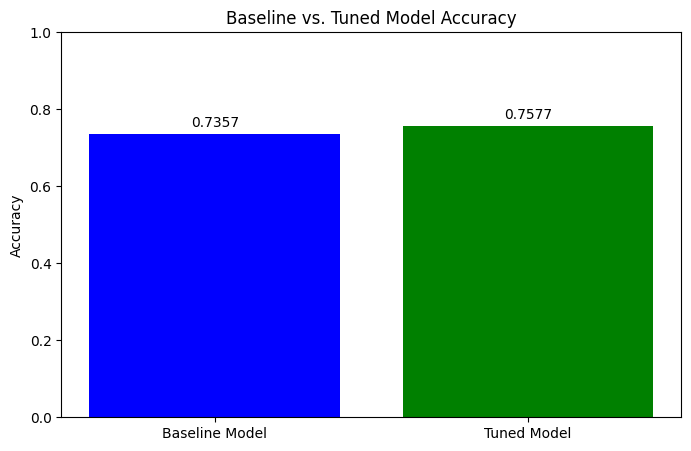

In [12]:

# --- 8. Graph ---
print("\n--- 8. Generating Graphs ---")

# Graph 1: Accuracy Comparison
plt.figure(figsize=(8, 5))
accuracies = [baseline_accuracy, tuned_accuracy]
labels = ['Baseline Model', 'Tuned Model']
colors = ['blue', 'green']
plt.bar(labels, accuracies, color=colors)
plt.ylabel('Accuracy')
plt.title('Baseline vs. Tuned Model Accuracy')
plt.ylim([0, 1.0])
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f'{acc:.4f}', ha='center', va='bottom')
plt.show()

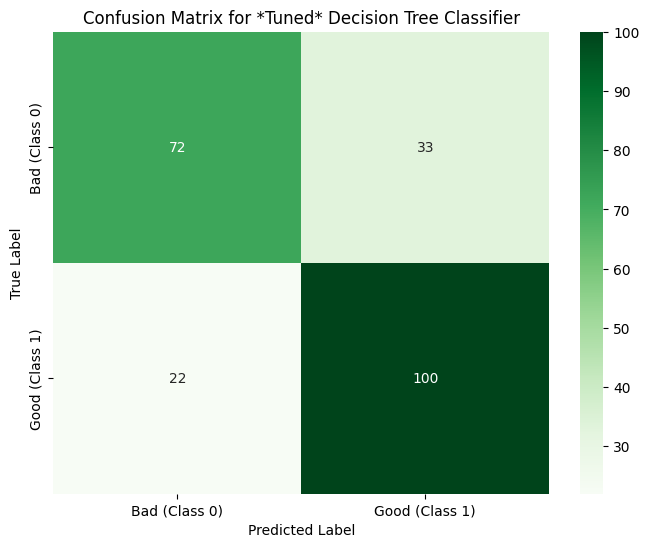

In [13]:
# Graph 2: Confusion Matrix for the *Tuned* Model
conf_matrix_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for *Tuned* Decision Tree Classifier')
plt.show()

In [14]:
# --- 9. Prediction (Example) ---
print("\n--- 9. Example Prediction with Tuned Model ---")

# Let's take the first 5 samples from the test set as new data
sample_data = X_test.iloc[0:5]
actual_labels = y_test.iloc[0:5]

# Use the tuned model to make predictions
sample_predictions = tuned_model.predict(sample_data)
sample_predictions_named = ['Good (Class 1)' if pred == 1 else 'Bad (Class 0)' for pred in sample_predictions]

print("Predicting on 5 new samples:")
print("\nPredicted Classes:")
print(sample_predictions_named)

print("\nActual Classes:")
print(actual_labels.values)


--- 9. Example Prediction with Tuned Model ---
Predicting on 5 new samples:

Predicted Classes:
['Bad (Class 0)', 'Bad (Class 0)', 'Bad (Class 0)', 'Good (Class 1)', 'Good (Class 1)']

Actual Classes:
[1 0 1 0 1]
